In [1]:
!pip install ucimlrepo


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Aadhithya\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [4]:
# loading the dataset & performing EDA locally
import pandas as pd
columns = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df = pd.read_csv('wdbc.data', header=None, names=columns)
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 rows:")
display(X.head())

print("\nTarget values:")
print(y.head())



Dataset shape: (569, 30)
Target shape: (569,)

First 5 rows:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target values:
0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: str


In [5]:
# encoding

y = y.map(
    {
        'B' : 0,
        'M' : 1
    }
)
print(y.value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [6]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFeature names:")
print(list(X.columns))

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nDataset information:")
print(X.info())

Number of samples: 569
Number of features: 30

Feature names:
['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30']

Missing values:
0

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   569 non-null    float64
 1   feature_2   569 non-null    float64
 2   feature_3   569 non-null    float64
 3   feature_4   569 non-null    float64
 4   feature_5   569 non-null    float64
 5   feature_6   569 non-null    float64
 6   feature_7   569 non-null    float64
 7   feature_8   569 n

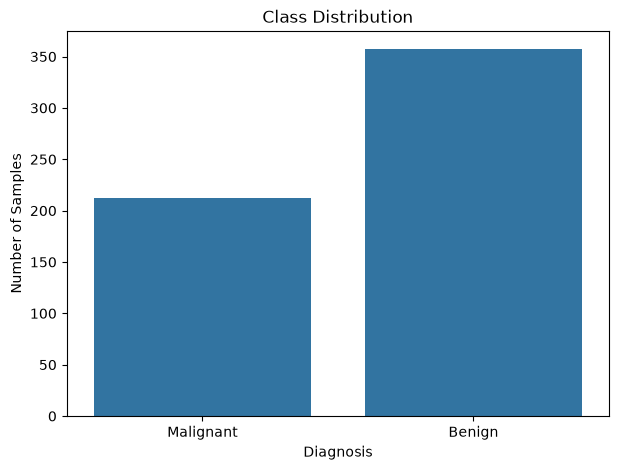

In [7]:
plt.figure(figsize=(7, 5))

sns.countplot(
    x=y.map({
        0: 'Benign',
        1: 'Malignant'
    })
)

plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.savefig("figures6/class_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

In [8]:
class_counts = y.value_counts().sort_index()

print("Benign samples:", class_counts[0])
print("Malignant samples:", class_counts[1])

Benign samples: 357
Malignant samples: 212


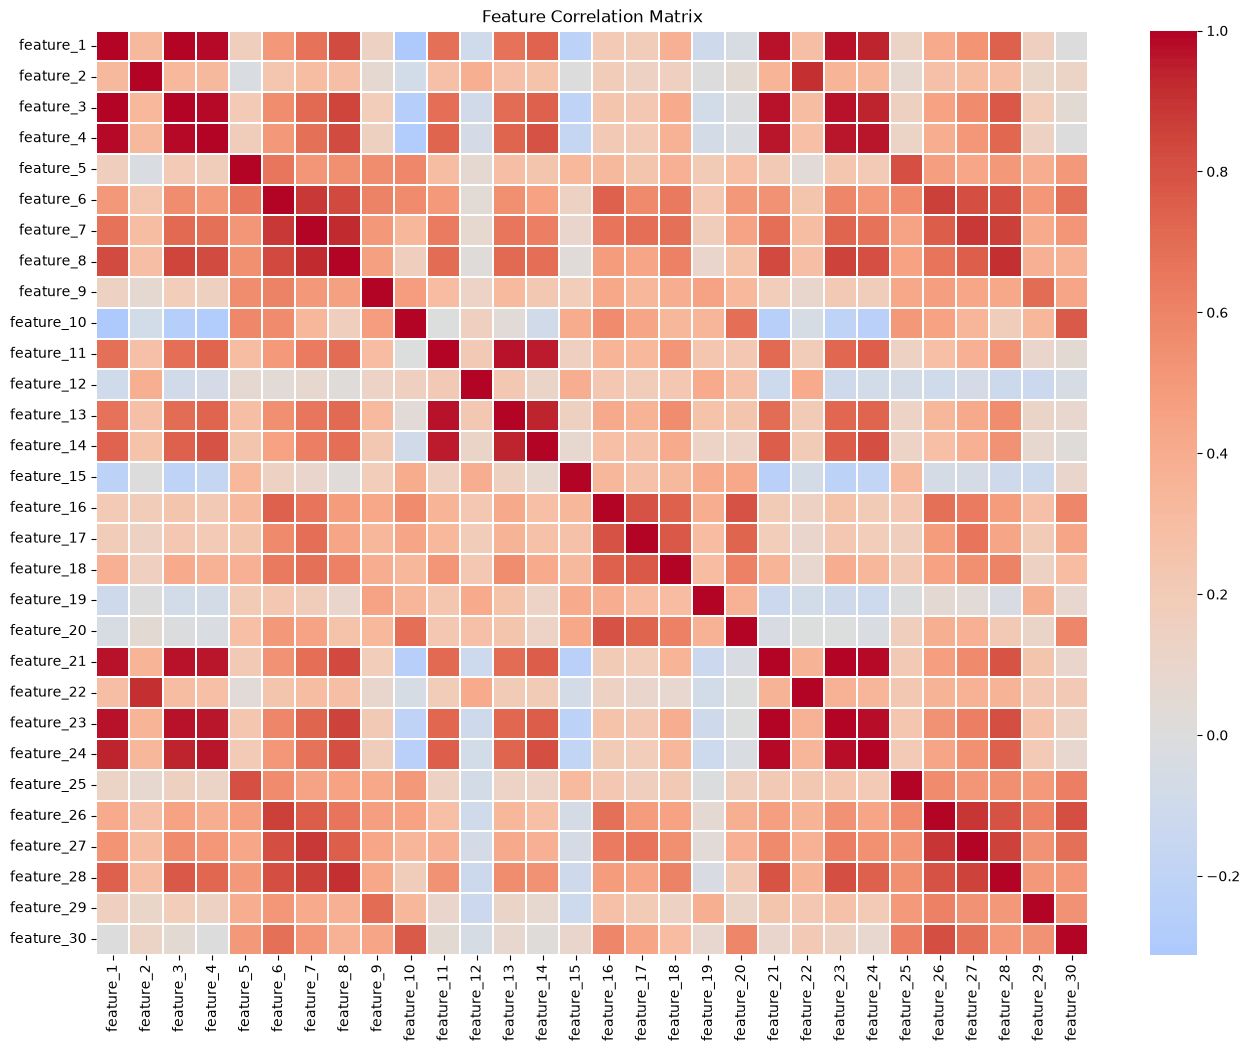

In [9]:
plt.figure(figsize=(16, 12))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Matrix")
plt.savefig("figures6/feature_correlation.png", dpi=600, bbox_inches="tight")
plt.show()

In [10]:
target_corr = X.copy()
target_corr["Diagnosis"] = y

target_correlations = (
    target_corr.corr()["Diagnosis"]
    .drop("Diagnosis")
    .sort_values(key=abs, ascending=False)
)
# features having the highest correlations with the target feature
print(target_correlations)

feature_28    0.793566
feature_23    0.782914
feature_8     0.776614
feature_21    0.776454
feature_3     0.742636
feature_24    0.733825
feature_1     0.730029
feature_4     0.708984
feature_7     0.696360
feature_27    0.659610
feature_6     0.596534
feature_26    0.590998
feature_11    0.567134
feature_13    0.556141
feature_14    0.548236
feature_22    0.456903
feature_25    0.421465
feature_29    0.416294
feature_2     0.415185
feature_18    0.408042
feature_5     0.358560
feature_9     0.330499
feature_30    0.323872
feature_16    0.292999
feature_17    0.253730
feature_20    0.077972
feature_15   -0.067016
feature_10   -0.012838
feature_12   -0.008303
feature_19   -0.006522
Name: Diagnosis, dtype: float64


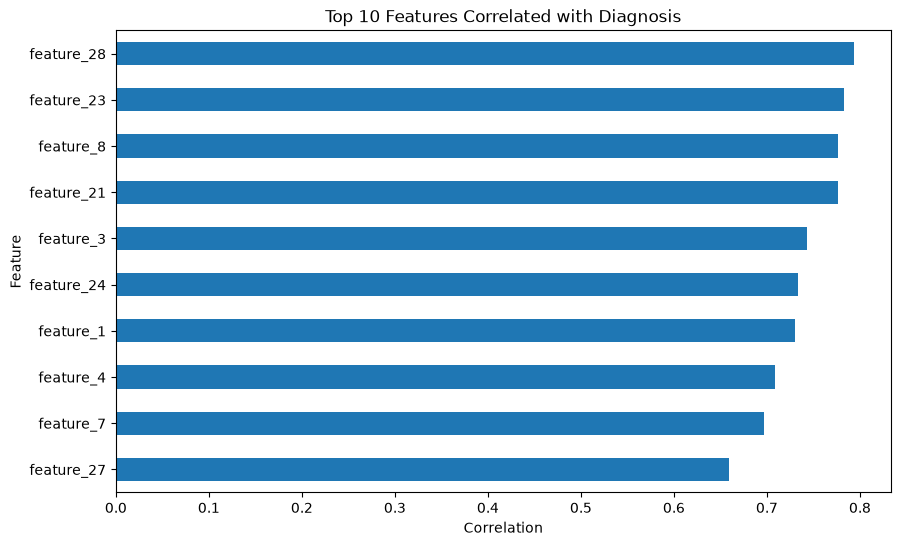

In [11]:
plt.figure(figsize=(10, 6))

target_correlations.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Features Correlated with Diagnosis")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.savefig("figures6/top_correlated_features.png", dpi=600, bbox_inches="tight")
plt.show()

In [12]:
# splitting into 80:20 split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [13]:

import os
import json
if not os.path.exists('figures6'):
    os.makedirs('figures6')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, roc_auc_score


In [14]:

print("--- Bagging Classifier ---")
bag_param_grid = {
    'n_estimators': [50, 100],
    'max_samples': [0.5, 0.8, 1.0],
    'max_features': [0.5, 0.8, 1.0]
}
bag_grid = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42),
    param_grid=bag_param_grid, cv=5, scoring='f1', n_jobs=-1, return_train_score=True
)
bag_grid.fit(X_train, y_train)
best_bag = bag_grid.best_estimator_
bag_acc_cv = cross_val_score(best_bag, X_train, y_train, cv=5, scoring='accuracy').mean()
bag_f1_cv = bag_grid.best_score_
print("Best params:", bag_grid.best_params_)
print("CV Acc:", bag_acc_cv, "CV F1:", bag_f1_cv)


--- Bagging Classifier ---


Best params: {'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 50}
CV Acc: 0.9692307692307693 CV F1: 0.9591147973321611


In [15]:

print("--- Gradient Boosting Classifier ---")
gb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid, cv=5, scoring='f1', n_jobs=-1, return_train_score=True
)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_
gb_acc_cv = cross_val_score(best_gb, X_train, y_train, cv=5, scoring='accuracy').mean()
gb_f1_cv = gb_grid.best_score_
print("Best params:", gb_grid.best_params_)
print("CV Acc:", gb_acc_cv, "CV F1:", gb_f1_cv)


--- Gradient Boosting Classifier ---


Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
CV Acc: 0.9560439560439562 CV F1: 0.9420462529893339


In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

print("--- Stacked Ensemble ---")
base_models = [
    ('svm', make_pipeline(StandardScaler(), SVC(probability=True, random_state=42))),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=42))
]
meta_learner = LogisticRegression(random_state=42)
stacked_clf = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)
stacked_clf.fit(X_train, y_train)
stack_acc_cv = cross_val_score(stacked_clf, X_train, y_train, cv=5, scoring='accuracy').mean()
stack_f1_cv = cross_val_score(stacked_clf, X_train, y_train, cv=5, scoring='f1').mean()
print("CV Acc:", stack_acc_cv, "CV F1:", stack_f1_cv)


--- Stacked Ensemble ---


C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packa

C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packa

C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packa

C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packa

...

C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packa

C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packa

C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packa

C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Aadhithya\AppData\Local\Programs\Python\Python313\Lib\site-packa

CV Acc: 0.9626373626373628 CV F1: 0.9500765900765902


In [ ]:

models = {'Bagging': best_bag, 'Boosting': best_gb, 'Stacked Ensemble': stacked_clf}
metrics_dict = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics_dict[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob)
    }

bag_cv_results = []
for i in range(len(bag_grid.cv_results_['params'])):
    bag_cv_results.append({
        'params': bag_grid.cv_results_['params'][i],
        'mean_test_score': bag_grid.cv_results_['mean_test_score'][i]
    })

gb_cv_results = []
for i in range(len(gb_grid.cv_results_['params'])):
    gb_cv_results.append({
        'params': gb_grid.cv_results_['params'][i],
        'mean_test_score': gb_grid.cv_results_['mean_test_score'][i]
    })

metrics_dict['CV_Bagging'] = {'best_params': bag_grid.best_params_, 'Acc': bag_acc_cv, 'F1': bag_f1_cv, 'cv_results': bag_cv_results}
metrics_dict['CV_Boosting'] = {'best_params': gb_grid.best_params_, 'Acc': gb_acc_cv, 'F1': gb_f1_cv, 'cv_results': gb_cv_results}
metrics_dict['CV_Stacking'] = {'Base Models': 'SVM, Naive Bayes, Decision Tree', 'Meta Learner': 'Logistic Regression', 'Acc': stack_acc_cv, 'F1': stack_f1_cv}

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        return super().default(obj)
        
with open('metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4, cls=NumpyEncoder)

display(pd.DataFrame({k: v for k, v in metrics_dict.items() if not k.startswith('CV_')}).T)


,Accuracy,Precision,Recall,F1 Score,AUC
Bagging,0.964912,1.0,0.904762,0.950000,0.994874
Boosting,0.964912,1.0,0.904762,0.950000,0.994048
Stacked Ensemble,0.973684,1.0,0.928571,0.962963,0.998016


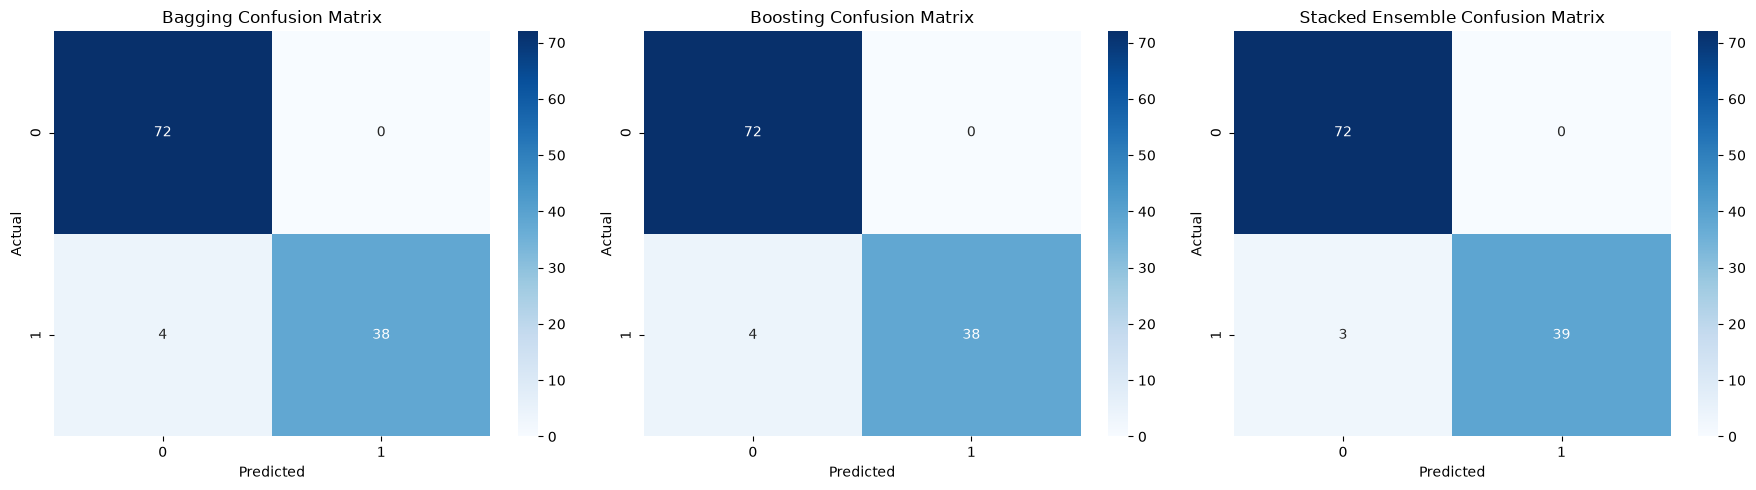

In [18]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig('figures6/confusion_matrices.png', dpi=600, bbox_inches='tight')
plt.show()


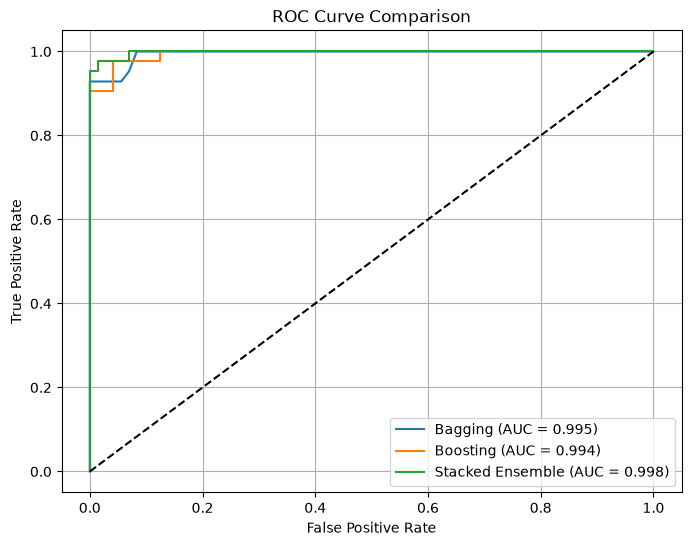

In [19]:

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('figures6/roc_curve.png', dpi=600, bbox_inches='tight')
plt.show()
